In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

os.makedirs("dataset/bih_dataset", exist_ok=True)
CLEAN = "dataset/bih_dataset/bih_hourly_clean.csv"
if not os.path.exists(CLEAN):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN, quiet=False)

gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output="shared", quiet=True)
sys.path.append("shared")
import bih_shared as bs

groups = bs.load_groups("shared")
coords = bs.load_coords("shared")
dist   = pd.read_csv("shared/station_distance_km.csv", index_col=0)
panel  = bs.load_panel(CLEAN, "shared")
split  = bs.load_split("shared")
TRAIN_END = pd.Timestamp(split["train"]["end"])
type_map = coords.set_index("station")["station_type"].to_dict()


## 1. Cross-station correlation

Only using **real** (non-`_filled`) measurements, restricted to the train period - same
ground rules as scoring, so this reflects what the model will actually be trained on.

In [2]:
POLLUTANTS = ["pm10", "pm25", "so2", "no2", "o3", "co"]

def real_series(station, pollutant):
    s = panel.get((station, pollutant))
    if s is None:
        return None
    real = s.y.where(~s.filled)
    return real[real.index <= TRAIN_END]

def correlation_matrix(pollutant, min_overlap=500):
    stations_with = sorted({st for (st, p) in panel if p == pollutant})
    wide = pd.DataFrame({st: real_series(st, pollutant) for st in stations_with})
    corr = wide.corr(min_periods=min_overlap)
    return corr, wide

pm10_corr, pm10_wide = correlation_matrix("pm10")
pm25_corr, pm25_wide = correlation_matrix("pm25")
print(f"{pm10_wide.shape[1]} stations with real PM10 data, {pm25_wide.shape[1]} with real PM2.5")
pm10_corr.round(2)


19 stations with real PM10 data, 16 with real PM2.5


,Banja Luka,Bihac,Bjelave,Brod,Doboj,Gacko,Hadzici,Ilidza,Ilijas,Isedlo,Livno,Mostar,Otoka,Prijedor,Trebinje,Tuzla-Trnovac,Ugljevik,Vijecnica,Vogosca
Banja Luka,1.00,0.49,0.49,0.50,0.49,0.23,0.43,0.62,0.60,-0.05,0.44,0.40,0.62,0.72,0.10,0.39,0.36,0.24,0.64
Bihac,0.49,1.00,0.45,0.16,0.25,0.18,0.33,0.44,0.45,0.07,0.36,0.02,0.43,0.43,0.11,0.23,0.22,0.32,0.39
Bjelave,0.49,0.45,1.00,0.27,0.44,0.17,0.55,0.64,0.58,0.09,0.34,0.23,0.66,0.42,0.12,0.49,0.26,0.68,0.77
Brod,0.50,0.16,0.27,1.00,0.50,0.19,0.37,0.48,0.44,-0.06,0.24,0.40,0.46,0.51,0.00,0.27,0.28,0.13,0.51
Doboj,0.49,0.25,0.44,0.50,1.00,0.25,0.41,0.52,0.49,-0.00,0.33,0.48,0.55,0.50,0.15,0.45,0.34,0.29,0.54
Gacko,0.23,0.18,0.17,0.19,0.25,1.00,0.24,0.29,0.28,0.09,0.26,0.34,0.29,0.24,0.25,0.21,0.19,0.17,0.32
Hadzici,0.43,0.33,0.55,0.37,0.41,0.24,1.00,0.74,0.72,0.01,0.27,0.18,0.71,0.37,0.09,0.44,0.13,0.48,0.69
Ilidza,0.62,0.44,0.64,0.48,0.52,0.29,0.74,1.00,0.80,0.01,0.40,0.43,0.90,0.60,0.11,0.43,0.27,0.45,0.87
Ilijas,0.60,0.45,0.58,0.44,0.49,0.28,0.72,0.80,1.00,-0.04,0.36,0.38,0.79,0.55,0.02,0.46,0.27,0.40,0.82
Isedlo,-0.05,0.07,0.09,-0.06,-0.00,0.09,0.01,0.01,-0.04,1.00,0.25,0.13,0.02,0.03,0.38,0.12,0.15,0.20,-0.02


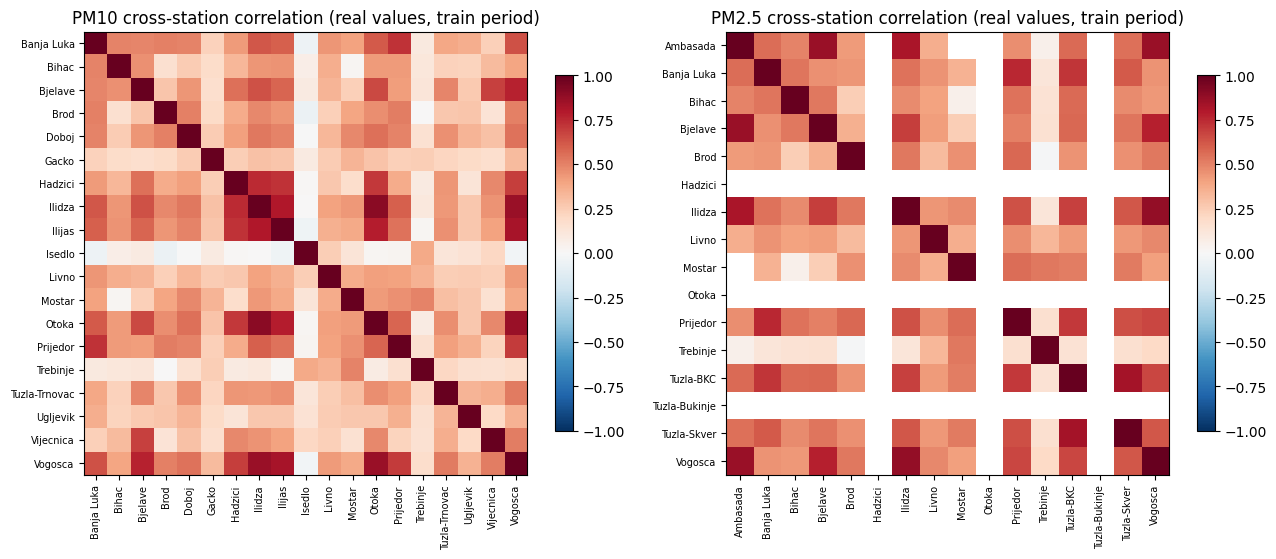

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, corr, name in [(axes[0], pm10_corr, "PM10"), (axes[1], pm25_corr, "PM2.5")]:
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(corr.index)), corr.index, fontsize=7)
    ax.set_title(f"{name} cross-station correlation (real values, train period)")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()


## 2. Correlation vs. distance

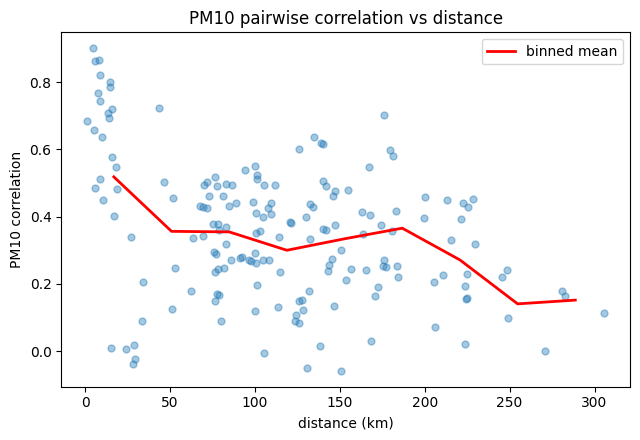

closest 10 pairs:
station_a station_b  distance_km  correlation           bin
  Bjelave Vijecnica         1.25     0.682888 (0.0, 33.962]
   Ilidza     Otoka         4.70     0.900232 (0.0, 33.962]
  Bjelave     Otoka         5.25     0.656755 (0.0, 33.962]
    Otoka Vijecnica         5.82     0.483946 (0.0, 33.962]
    Otoka   Vogosca         6.02     0.864228 (0.0, 33.962]
  Bjelave   Vogosca         7.46     0.768147 (0.0, 33.962]
   Ilidza   Vogosca         8.20     0.866898 (0.0, 33.962]
Vijecnica   Vogosca         8.67     0.510502 (0.0, 33.962]
  Hadzici    Ilidza         8.78     0.743701 (0.0, 33.962]
   Ilijas   Vogosca         8.87     0.820517 (0.0, 33.962]


In [4]:
def corr_vs_distance(corr, dist_df):
    rows = []
    stations = corr.columns
    for i, a in enumerate(stations):
        for b in stations[i+1:]:
            if a in dist_df.index and b in dist_df.columns:
                d, c = dist_df.loc[a, b], corr.loc[a, b]
                if pd.notna(d) and pd.notna(c):
                    rows.append((a, b, d, c))
    return pd.DataFrame(rows, columns=["station_a", "station_b", "distance_km", "correlation"])

cd_pm10 = corr_vs_distance(pm10_corr, dist)

plt.figure(figsize=(6.5, 4.5))
plt.scatter(cd_pm10.distance_km, cd_pm10.correlation, alpha=0.4, s=25)
bins = np.linspace(0, cd_pm10.distance_km.max(), 10)
cd_pm10["bin"] = pd.cut(cd_pm10.distance_km, bins)
trend = cd_pm10.groupby("bin", observed=True).correlation.mean()
mids = [b.mid for b in trend.index]
plt.plot(mids, trend.values, color="red", lw=2, label="binned mean")
plt.xlabel("distance (km)"); plt.ylabel("PM10 correlation")
plt.title("PM10 pairwise correlation vs distance")
plt.legend(); plt.tight_layout(); plt.show()

print("closest 10 pairs:")
print(cd_pm10.sort_values("distance_km").head(10).to_string(index=False))


## 3. Does `same_type` add anything beyond distance alone?

Compares same-type vs different-type pairs, then repeats it restricted to the closer half of
distances only - controls for the fact that same-type stations might just happen to be
closer together on average, which would make distance the real driver, not type.

In [5]:
cd_pm10["same_type"] = cd_pm10.apply(
    lambda r: type_map.get(r.station_a) == type_map.get(r.station_b)
              and type_map.get(r.station_a) not in (None, "unknown"), axis=1)

print("All pairs:")
print(cd_pm10.groupby("same_type").correlation.agg(["mean", "median", "count"]))

close_half = cd_pm10[cd_pm10.distance_km < cd_pm10.distance_km.median()]
print("\nOnly the closer half of distances (controls for type/distance confound):")
print(close_half.groupby("same_type").correlation.agg(["mean", "median", "count"]))


All pairs:
               mean    median  count
same_type                           
False      0.348002  0.354428    142
True       0.384315  0.361430     29

Only the closer half of distances (controls for type/distance confound):
               mean    median  count
same_type                           
False      0.385226  0.399104     71
True       0.508516  0.487412     14


## 4. Per-station level differences

Directly re-tests the Sarajevo finding ("PM10 differs a lot by station because location
matters") at full BIH scale, with a formal test rather than eyeballing a boxplot.

<Figure size 1000x500 with 0 Axes>

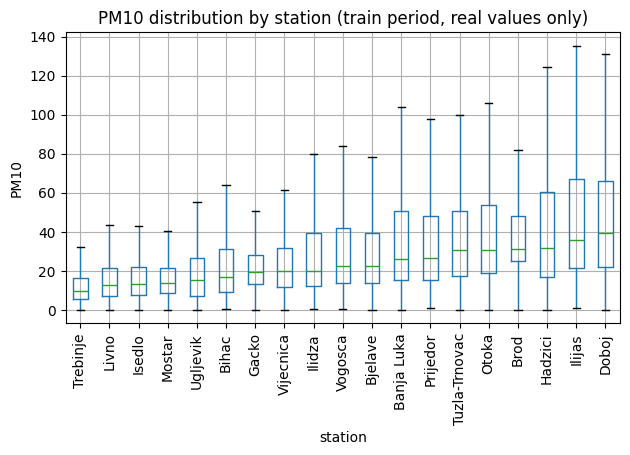

Kruskal-Wallis H=68878.6  p=0.00e+00
very small p => station identity matters a lot for PM10 level, matching the Sarajevo finding


In [6]:
from scipy import stats

order = pm10_wide.median().sort_values().index
pm10_long = pm10_wide.melt(var_name="station", value_name="pm10").dropna()
pm10_long["station"] = pd.Categorical(pm10_long.station, categories=order, ordered=True)

plt.figure(figsize=(10, 5))
pm10_long.boxplot(column="pm10", by="station", rot=90, showfliers=False)
plt.title("PM10 distribution by station (train period, real values only)")
plt.suptitle(""); plt.ylabel("PM10")
plt.tight_layout(); plt.show()

groups_data = [pm10_wide[st].dropna() for st in order]
stat, p = stats.kruskal(*groups_data)
print(f"Kruskal-Wallis H={stat:.1f}  p={p:.2e}")
print("very small p => station identity matters a lot for PM10 level, matching the Sarajevo finding"
      if p < 0.01 else
      "p not small => less station-to-station difference than expected, worth double-checking")


## 5. Diurnal profile per station

Traffic-influenced stations typically show morning/evening rush-hour peaks; background
stations show a flatter or single-peak profile. If profiles cluster by `station_type`, that's
evidence the `same_type` edge is capturing something real and useful, beyond what section 3
already showed for raw correlation.

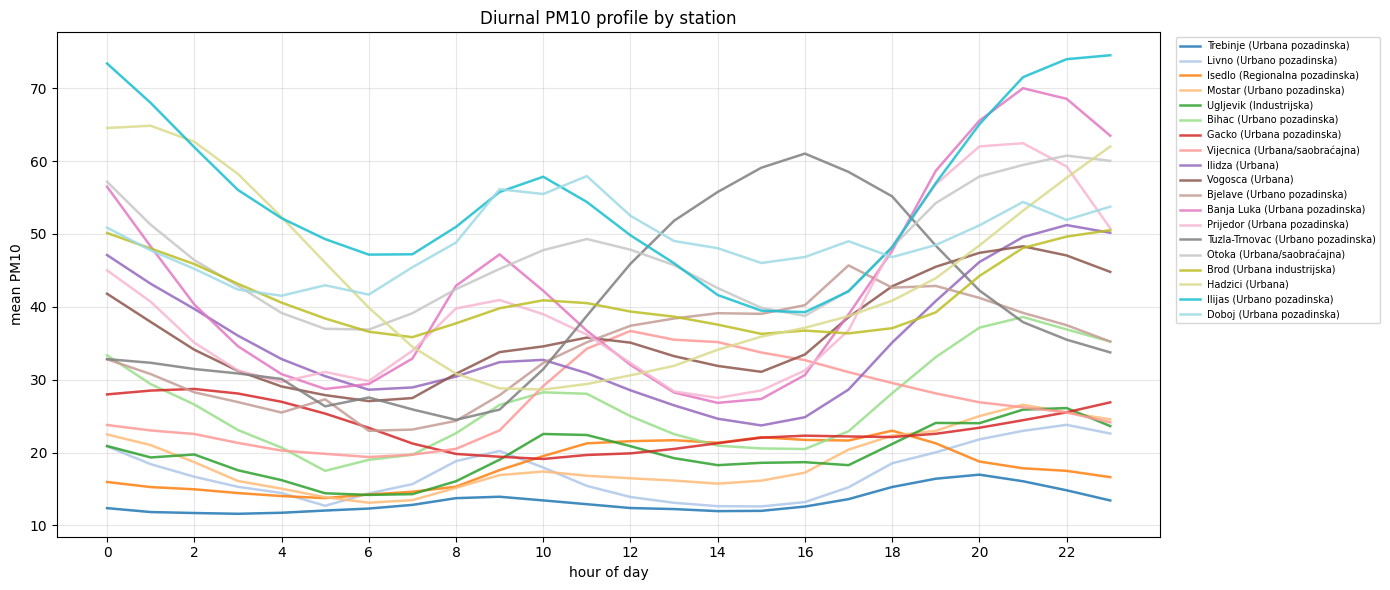

In [8]:
diurnal = pm10_wide.copy()
diurnal["hour"] = diurnal.index.hour
prof = diurnal.groupby("hour")[order].mean()

n = len(order)
cmap = plt.cm.tab20(np.linspace(0, 1, min(n, 20)))
if n > 20:
    cmap = np.vstack([cmap, plt.cm.tab20b(np.linspace(0, 1, n - 20))])

plt.figure(figsize=(14, 6))
for st, color in zip(order, cmap):
    plt.plot(prof.index, prof[st], color=color, lw=1.8, alpha=0.85,
              label=f"{st} ({type_map.get(st, 'unknown')})")
plt.xlabel("hour of day"); plt.ylabel("mean PM10")
plt.title("Diurnal PM10 profile by station")
plt.legend(fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Seasonal profile per station


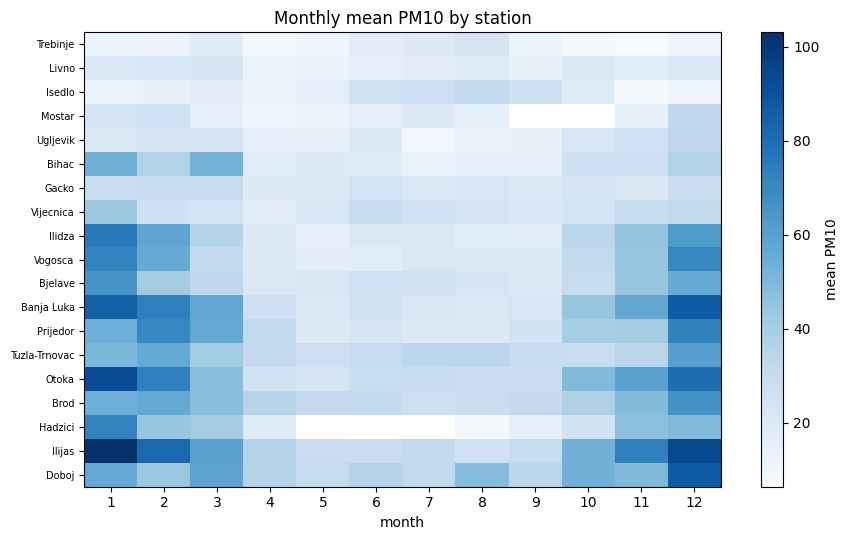

winter-mean minus summer-mean PM10, per station:
Ilijas           64.8
Banja Luka       59.6
Otoka            53.2
Vogosca          47.3
Hadzici          46.6
Ilidza           46.1
Prijedor         45.5
Brod             30.3
Bjelave          29.6
Bihac            26.6
Doboj            23.8
Tuzla-Trnovac    23.6
Ugljevik         11.7
Mostar           10.8
Vijecnica         7.2
Gacko             6.7
Livno             3.7
Trebinje         -8.2
Isedlo          -15.7


In [9]:
monthly = pm10_wide.copy()
monthly["month"] = monthly.index.month
m = monthly.groupby("month")[order].mean()

plt.figure(figsize=(9, 5.5))
im = plt.imshow(m.T.values, aspect="auto", cmap="Blues")
plt.yticks(range(len(order)), order, fontsize=7)
plt.xticks(range(12), range(1, 13))
plt.colorbar(im, label="mean PM10")
plt.title("Monthly mean PM10 by station")
plt.xlabel("month")
plt.tight_layout(); plt.show()

# how much does the winter/summer swing itself vary station to station?
swing = (m.loc[[12, 1, 2]].mean() - m.loc[[6, 7, 8]].mean()).sort_values(ascending=False)
print("winter-mean minus summer-mean PM10, per station:")
print(swing.round(1).to_string())


## 7. Lagged cross-correlation between neighbor pairs

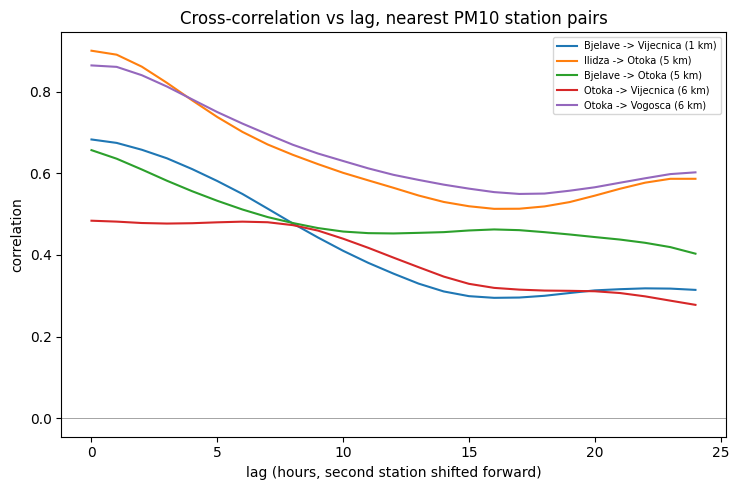

In [10]:
def lagged_corr(a, b, max_lag=24):
    df = pd.concat([a, b], axis=1).dropna()
    df.columns = ["a", "b"]
    return {lag: df["a"].corr(df["b"].shift(lag)) for lag in range(0, max_lag + 1)}

closest_pairs = cd_pm10.sort_values("distance_km").head(5)
plt.figure(figsize=(7.5, 5))
for _, row in closest_pairs.iterrows():
    lc = lagged_corr(pm10_wide[row.station_a], pm10_wide[row.station_b])
    plt.plot(list(lc.keys()), list(lc.values()),
             label=f"{row.station_a} -> {row.station_b} ({row.distance_km:.0f} km)")
plt.xlabel("lag (hours, second station shifted forward)"); plt.ylabel("correlation")
plt.title("Cross-correlation vs lag, nearest PM10 station pairs")
plt.axhline(0, color="grey", lw=0.5)
plt.legend(fontsize=7); plt.tight_layout(); plt.show()
